In [1]:
%matplotlib inline
import sys
sys.path.insert(0, '..')

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from src import (
    load_experiment, get_transform, get_loaders_from_config,
    collect_layer_inputs,
    bft,
    evaluate,
    # Stimulus-conditioned BFT analysis
    extract_tree_nodes,
    compute_node_activations,
    plot_factor_tree,
    extract_factor_fingerprint,
    extract_fingerprint_matrix,
    compute_stimulus_similarity,
    project_stimuli_onto_tree,
)

import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


# Notebook 06: Stimulus-Conditioned BFT Factor Analysis

Three analyses on a pre-computed BFT factor tree:

1. **Factor tree visualisation** — colour the BFT tree by how strongly a given stimulus (or class average) activates each factor branch.
2. **Factor fingerprints & stimulus similarity** — represent each stimulus as a concatenated vector of its img_factors loadings across all tree nodes; compute pairwise cosine similarity.
3. **OOD / adversarial projection** — fix the BFT factors and project new stimuli onto them via NNLS, without refitting NMF.

## Section 1: Setup — load model, data, and run BFT

In [2]:
# ── Configure experiment ──────────────────────────────────────────────────────
EXPERIMENT_DIR = '../experiments/mnist_even_odd_mlp_8_4_0134'
N_BRANCHES     = [8, 2, 2]   # branching factor per layer (last → first)
K_MAX          = [10, 1, 2]  # NMF rank cap per layer (last → first)
STIM_THRESHOLD = 0.7         # zero out lowest X% of stimuli by weight
AUTO_METHOD    = 'structural'
AUTO_THRESHOLD = 0.70

model, cfg = load_experiment(EXPERIMENT_DIR, device)
train_loader, test_loader = get_loaders_from_config(cfg)
label_transform = get_transform(cfg['label_transform'])

_, test_acc = evaluate(model, test_loader,
                       criterion=nn.CrossEntropyLoss(),
                       label_transform=label_transform, device=device)
print(f'Test accuracy: {test_acc:.4f}')

linear_indices = model.linear_layer_indices()
LAYER_SIZES    = [model.layers[li].out_features for li in linear_indices]
CLASS_NAMES    = ({0: 'even', 1: 'odd'} if cfg['label_transform'] == 'even_odd'
                  else {i: str(i) for i in range(LAYER_SIZES[-1])})
IMAGE_SIDE     = cfg['input_side']
print(f'Architecture: {LAYER_SIZES}')

Test accuracy: 0.9929
Architecture: [8, 4, 2]


In [3]:
data = collect_layer_inputs(
    model, test_loader.dataset,
    label_transform=label_transform,
    n_per_class=None,
    device=device,
)

all_images   = data['images']        # (N, C, H, W)
all_targets  = data['targets']       # (N,) task labels
all_digits   = data['digits']        # (N,) original digit labels
layer_inputs = data['layer_inputs']  # list[(N, n_in)] forward order
layer_acts   = data['layer_acts']    # list[(N, n_out)]
n_samples    = len(all_images)
print(f'Collected {n_samples} samples')
print(f'Class distribution: {dict(zip(*np.unique(all_targets, return_counts=True)))}')

Collected 4078 samples
Class distribution: {np.int64(0): np.int64(1946), np.int64(1): np.int64(2132)}


In [4]:
tree_root = bft(
    model, layer_inputs,
    k_max=K_MAX, n_branches=N_BRANCHES,
    method=AUTO_METHOD, threshold=AUTO_THRESHOLD,
    stimulus_threshold=STIM_THRESHOLD,
    weighting='img_selectivity',
    verbose=1,
)

# Flat list of all nodes in BFS order
tree_nodes = extract_tree_nodes(tree_root)
print(f'Tree: {len(tree_nodes)} nodes total')
for e in tree_nodes:
    depth = len(e['path'])
    print(f"  {'  ' * depth}[{e['node_id']}] L{e['layer_idx']} {e['layer_name']!r}  "
          f"K={len(e['lambdas'])}  f_idx={e['factor_idx']}")

[BFT] Layer 3/3 '2' (fc)  path=[]
[BFT] Layer 2/3 '1' (fc)  path=[0]
[BFT] Layer 1/3 '0' (fc)  path=[0, 0]
[BFT] Layer 2/3 '1' (fc)  path=[1]
[BFT] Layer 1/3 '0' (fc)  path=[1, 0]
Tree: 5 nodes total
  [()] L2 '2'  K=2  f_idx=0
    [(0,)] L1 '1'  K=1  f_idx=0
    [(1,)] L1 '1'  K=1  f_idx=1
      [(0, 0)] L0 '0'  K=9  f_idx=0
      [(1, 0)] L0 '0'  K=9  f_idx=0


## Section 2: Factor Tree Visualisation

Render the BFT tree as a directed graph. Each node is a (layer, factor) pair.
Node colour = average stimulus activation for the selected stimulus or class.

- **`mode='stimulus_weights'`** (default): non-root nodes are coloured by the importance
  weight propagated from the parent layer — a direct measure of branch relevance.
- **`mode='img_factor_0'`**: all nodes show their top-factor loading for the stimulus.

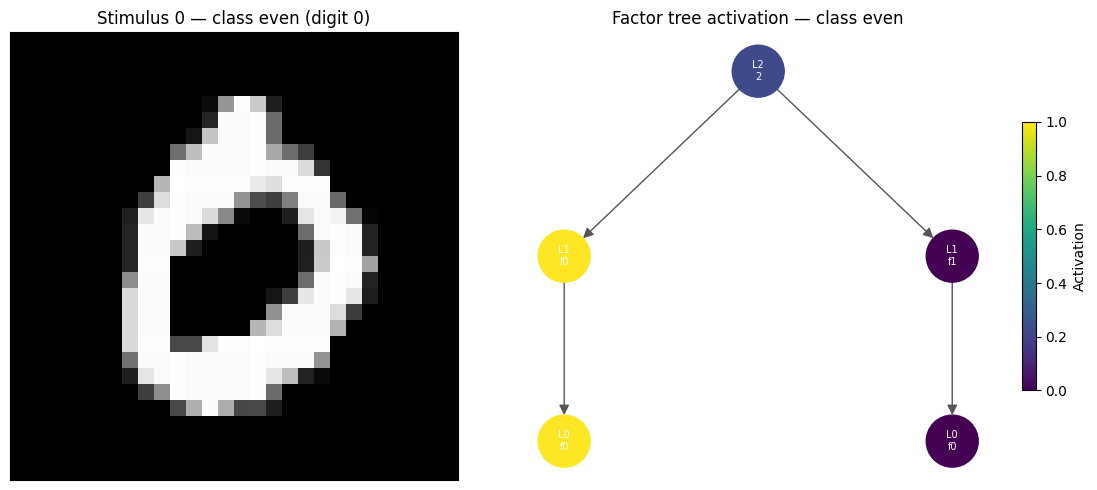

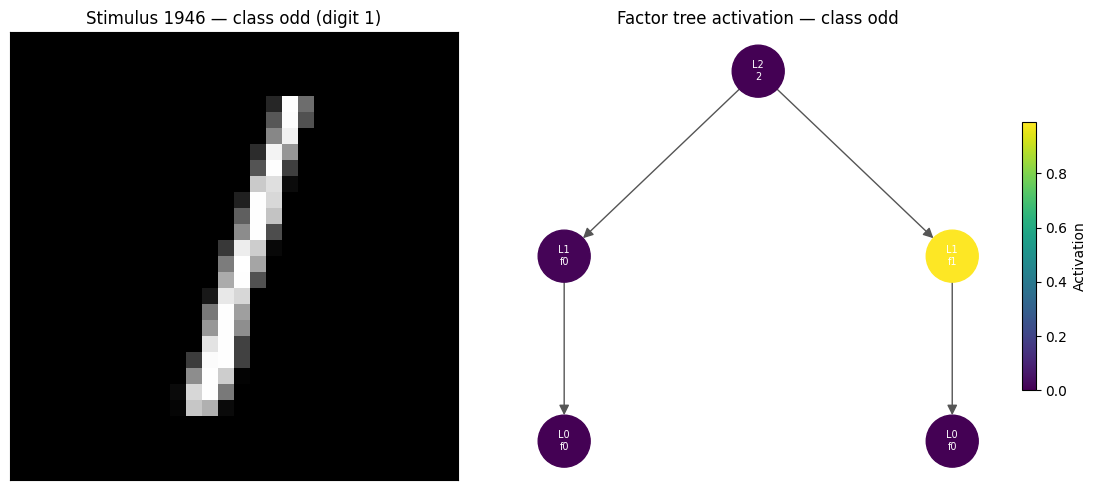

In [5]:
# ── Single stimulus ───────────────────────────────────────────────────────────
# Pick one example from each class
for cl in sorted(np.unique(all_targets)):
    cl_indices = np.where(all_targets == cl)[0]
    s = int(cl_indices[0])          # first correctly-classified sample of this class

    activations = compute_node_activations(tree_nodes, [s], mode='stimulus_weights')

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(all_images[s].squeeze(), cmap='gray')
    axes[0].set(title=f'Stimulus {s} — class {CLASS_NAMES.get(cl, cl)} (digit {all_digits[s]})',
                xticks=[], yticks=[])

    plot_factor_tree(
        tree_nodes, activations,
        ax=axes[1],
        title=f'Factor tree activation — class {CLASS_NAMES.get(cl, cl)}',
    )
    plt.tight_layout()
    plt.show()

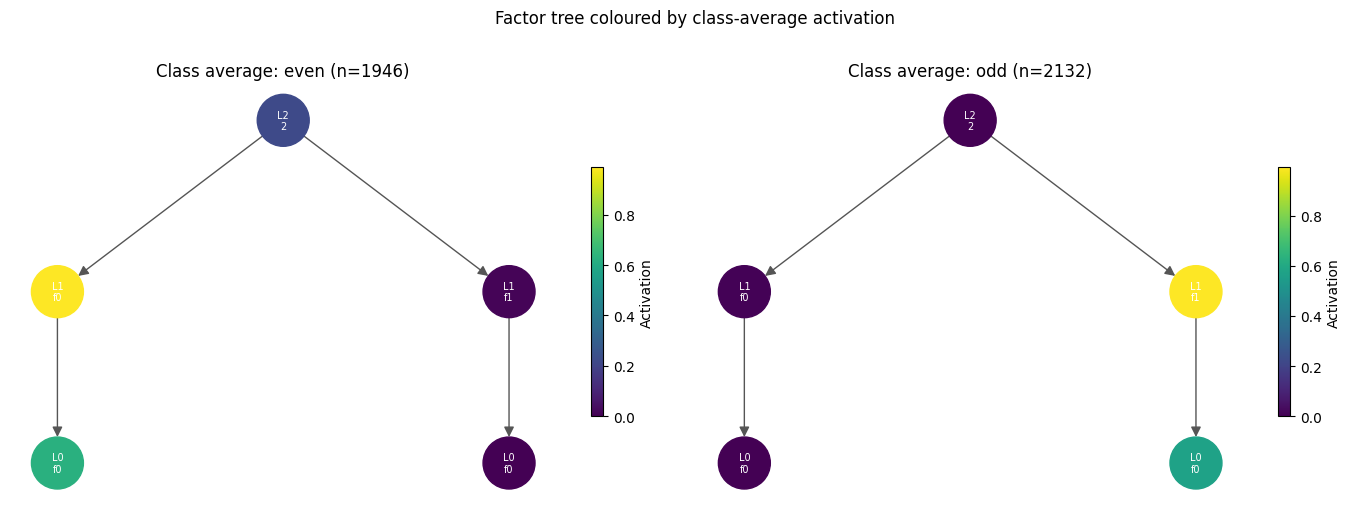

In [6]:
# ── Class-average activation ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(np.unique(all_targets)), figsize=(7 * len(np.unique(all_targets)), 5))
axes = np.atleast_1d(axes)

for ax, cl in zip(axes, sorted(np.unique(all_targets))):
    cl_indices = np.where(all_targets == cl)[0]
    activations = compute_node_activations(tree_nodes, cl_indices, mode='stimulus_weights')
    plot_factor_tree(
        tree_nodes, activations, ax=ax,
        title=f'Class average: {CLASS_NAMES.get(cl, cl)} (n={len(cl_indices)})',
    )

plt.suptitle('Factor tree coloured by class-average activation', y=1.01)
plt.tight_layout()
plt.show()

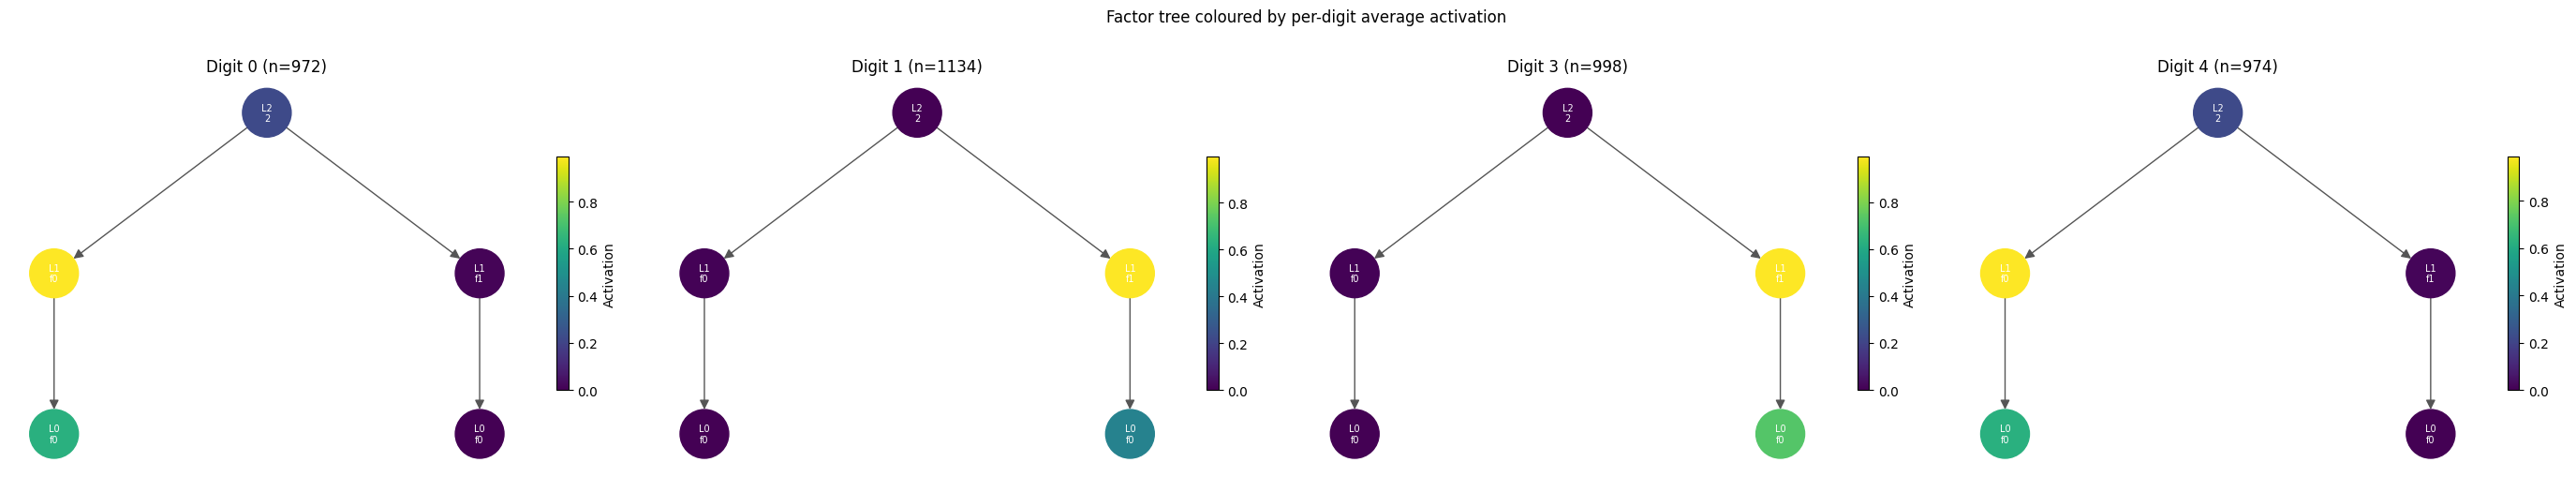

In [7]:
# ── Per-digit average (for MNIST digit tasks) ─────────────────────────────────
unique_digits = sorted(np.unique(all_digits))
ncols = min(5, len(unique_digits))
nrows = int(np.ceil(len(unique_digits) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows), squeeze=False)

for i, d in enumerate(unique_digits):
    ax = axes[i // ncols][i % ncols]
    d_indices = np.where(all_digits == d)[0]
    activations = compute_node_activations(tree_nodes, d_indices, mode='stimulus_weights')
    plot_factor_tree(tree_nodes, activations, ax=ax, title=f'Digit {d} (n={len(d_indices)})')

# Hide empty axes
for j in range(len(unique_digits), nrows * ncols):
    axes[j // ncols][j % ncols].set_visible(False)

plt.suptitle('Factor tree coloured by per-digit average activation', y=1.01)
plt.tight_layout()
plt.show()

## Section 3: Factor Fingerprints & Stimulus Similarity

Each stimulus is represented as a concatenation of its `img_factors[s, :]` across **all** tree nodes (all K factors, not just the followed one). Pairwise cosine similarity reveals whether the network's factor decomposition separates classes.

In [8]:
# Build the fingerprint matrix for all test samples
all_indices = np.arange(n_samples)
F = extract_fingerprint_matrix(tree_root, all_indices)   # (N, fingerprint_dim)
print(f'Fingerprint matrix: {F.shape}  — dim = {F.shape[1]} = Σ K_i across all nodes')

# Confirm dimension = sum of K values across nodes
expected_dim = sum(len(e['lambdas']) for e in tree_nodes)
print(f'Expected dim (Σ K_i): {expected_dim}  ✓' if F.shape[1] == expected_dim else
      f'MISMATCH: got {F.shape[1]}, expected {expected_dim}')

Fingerprint matrix: (4078, 22)  — dim = 22 = Σ K_i across all nodes
Expected dim (Σ K_i): 22  ✓


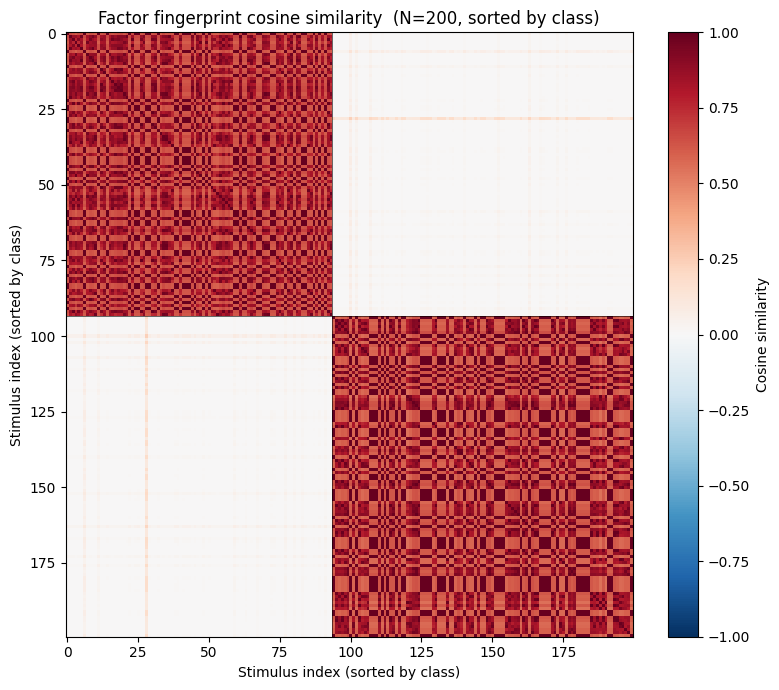

In [9]:
# ── Similarity matrix (subsample for readability if N is large) ───────────────
MAX_VIZ = 200   # max stimuli to show in heatmap; set to None for all

rng = np.random.default_rng(42)
if MAX_VIZ is not None and n_samples > MAX_VIZ:
    viz_idx = rng.choice(n_samples, MAX_VIZ, replace=False)
    viz_idx = viz_idx[np.argsort(all_targets[viz_idx])]   # sort by class for readability
else:
    viz_idx = np.argsort(all_targets)   # all, sorted by class

F_viz    = F[viz_idx]
targets_viz = all_targets[viz_idx]
S = compute_stimulus_similarity(F_viz, metric='cosine')

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(S, aspect='auto', interpolation='nearest',
               cmap='RdBu_r', vmin=-1, vmax=1)
fig.colorbar(im, ax=ax, label='Cosine similarity')

# Mark class boundaries
for cl in np.unique(targets_viz):
    boundary = np.where(np.diff((targets_viz == cl).astype(int)))[0]
    for b in boundary:
        ax.axhline(b + 0.5, color='k', lw=0.5, alpha=0.5)
        ax.axvline(b + 0.5, color='k', lw=0.5, alpha=0.5)

ax.set(title=f'Factor fingerprint cosine similarity  (N={len(viz_idx)}, sorted by class)',
       xlabel='Stimulus index (sorted by class)',
       ylabel='Stimulus index (sorted by class)')
plt.tight_layout()
plt.show()

/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


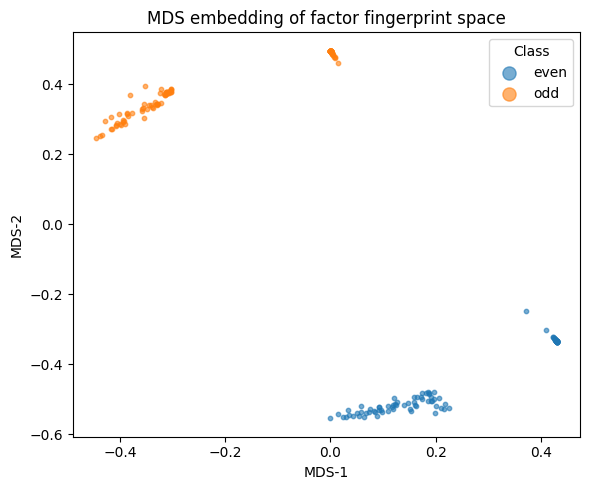

In [10]:
# ── 2-D MDS embedding of the fingerprint space ────────────────────────────────
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import cosine_distances

dist_matrix = cosine_distances(F_viz)
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=0, n_init=4)
coords = mds.fit_transform(dist_matrix)  # (n_viz, 2)

fig, ax = plt.subplots(figsize=(6, 5))
cmap_tab = plt.get_cmap('tab10')
for cl in sorted(np.unique(targets_viz)):
    mask = targets_viz == cl
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=[cmap_tab(cl % 10)], s=10, alpha=0.6,
               label=CLASS_NAMES.get(cl, str(cl)))

ax.legend(markerscale=3, title='Class')
ax.set(title='MDS embedding of factor fingerprint space', xlabel='MDS-1', ylabel='MDS-2')
plt.tight_layout()
plt.show()

Cosine similarity statistics (mean ± std):
  Overall: 0.393 ± 0.396
  Intra-class: 0.770 ± 0.160
  Inter-class: 0.015 ± 0.048


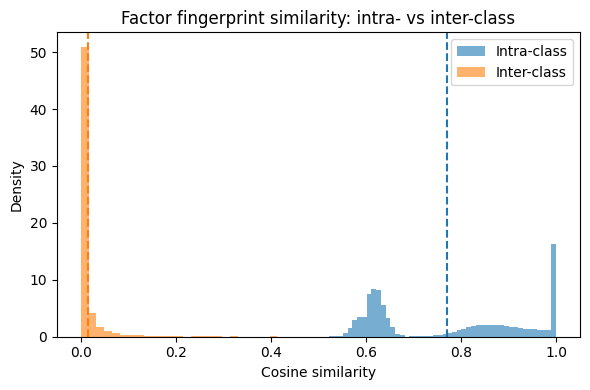

In [11]:
# ── Intra-class vs inter-class similarity statistics ─────────────────────────
S_all = compute_stimulus_similarity(F, metric='cosine')
classes = sorted(np.unique(all_targets))

print('Cosine similarity statistics (mean ± std):')
print(f'  Overall: {S_all.mean():.3f} ± {S_all.std():.3f}')
intra_vals, inter_vals = [], []
for ci, cl in enumerate(classes):
    mask = all_targets == cl
    intra = S_all[np.ix_(mask, mask)]
    upper_tri = intra[np.triu_indices_from(intra, k=1)]
    intra_vals.extend(upper_tri)
    for cl2 in classes[ci + 1:]:
        mask2 = all_targets == cl2
        inter_vals.extend(S_all[np.ix_(mask, mask2)].ravel())

intra_arr = np.array(intra_vals)
inter_arr = np.array(inter_vals)
print(f'  Intra-class: {intra_arr.mean():.3f} ± {intra_arr.std():.3f}')
print(f'  Inter-class: {inter_arr.mean():.3f} ± {inter_arr.std():.3f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(intra_arr, bins=60, alpha=0.6, label='Intra-class', density=True)
ax.hist(inter_arr, bins=60, alpha=0.6, label='Inter-class', density=True)
ax.axvline(intra_arr.mean(), color='C0', ls='--', lw=1.5)
ax.axvline(inter_arr.mean(), color='C1', ls='--', lw=1.5)
ax.set(xlabel='Cosine similarity', ylabel='Density',
       title='Factor fingerprint similarity: intra- vs inter-class')
ax.legend()
plt.tight_layout()
plt.show()

## Section 4: OOD / Adversarial Projection

Fix the BFT `neural_factors` and project new stimuli (not seen during BFT) onto them via NNLS. This gives `img_factors` for the new stimuli that can then be fed into the tree visualisation and fingerprint similarity analyses above.

**What `project_stimuli_onto_tree` does:**
1. Forward-pass the new stimuli to collect activations at each layer (you provide `new_layer_inputs`).
2. At each BFT node, compute the joint arbor from those activations.
3. Solve NNLS: `min_{x≥0} ||neural_factors @ x − joint[s]||²` for each stimulus `s`.

**Approximation note:** The original `neural_factors` were fitted with propagated stimulus weights, but the projection uses uniform weights — a deliberate simplification.

In [12]:
# ── Sanity check: re-project training stimuli ─────────────────────────────────
# The NNLS img_factors_new for training stimuli should correlate with the
# original img_factors stored in the tree.
#
# Here we use the same layer_inputs (training data) as a sanity check.
# In practice, replace layer_inputs_new with activations for your OOD stimuli.

# Collect activations for the first N_OOD training samples
N_OOD       = 100
ood_indices = np.arange(N_OOD)
layer_inputs_new = [li[ood_indices] for li in layer_inputs]  # same data, sliced

projected_root = project_stimuli_onto_tree(tree_root, layer_inputs_new)
projected_nodes = extract_tree_nodes(projected_root)
print(f'Projected tree: {len(projected_nodes)} nodes, {N_OOD} new stimuli')

Projected tree: 5 nodes, 100 new stimuli


In [13]:
# ── Sanity check: original vs projected img_factors at each node ──────────────
print('Per-node NNLS reconstruction quality (Pearson r, RMSE):')
for orig, proj in zip(tree_nodes, projected_nodes):
    # Compare K=0 factor only (the most important) across the N_OOD stimuli
    orig_f = orig['img_factors'][ood_indices, 0]
    proj_f = proj['img_factors'][:, 0]
    r = float(np.corrcoef(orig_f, proj_f)[0, 1])
    rmse = float(np.sqrt(np.mean((orig_f - proj_f) ** 2)))
    print(f"  [{orig['node_id']}] L{orig['layer_idx']} {orig['layer_name']!r}  "
          f"r={r:.3f}  RMSE={rmse:.4f}")

Per-node NNLS reconstruction quality (Pearson r, RMSE):
  [()] L2 '2'  r=0.966  RMSE=0.0917
  [(0,)] L1 '1'  r=0.537  RMSE=0.1404
  [(1,)] L1 '1'  r=nan  RMSE=0.0173
  [(0, 0)] L0 '0'  r=0.754  RMSE=0.0289
  [(1, 0)] L0 '0'  r=nan  RMSE=0.0029


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


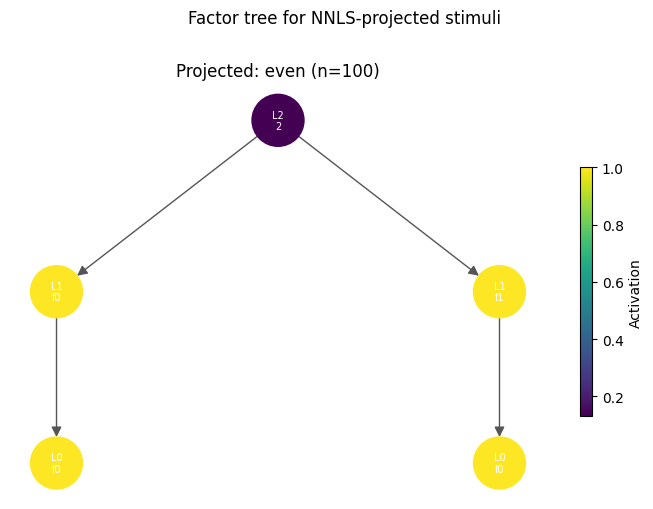

In [14]:
# ── OOD tree visualisation ────────────────────────────────────────────────────
# Visualise the projected tree for each class in the OOD slice
ood_targets = all_targets[ood_indices]

fig, axes = plt.subplots(1, len(np.unique(ood_targets)), figsize=(7 * len(np.unique(ood_targets)), 5))
axes = np.atleast_1d(axes)

for ax, cl in zip(axes, sorted(np.unique(ood_targets))):
    cl_local = np.where(ood_targets == cl)[0]   # indices into N_OOD
    activations = compute_node_activations(projected_nodes, cl_local, mode='stimulus_weights')
    plot_factor_tree(
        projected_nodes, activations, ax=ax,
        title=f'Projected: {CLASS_NAMES.get(cl, cl)} (n={len(cl_local)})',
    )

plt.suptitle('Factor tree for NNLS-projected stimuli', y=1.01)
plt.tight_layout()
plt.show()

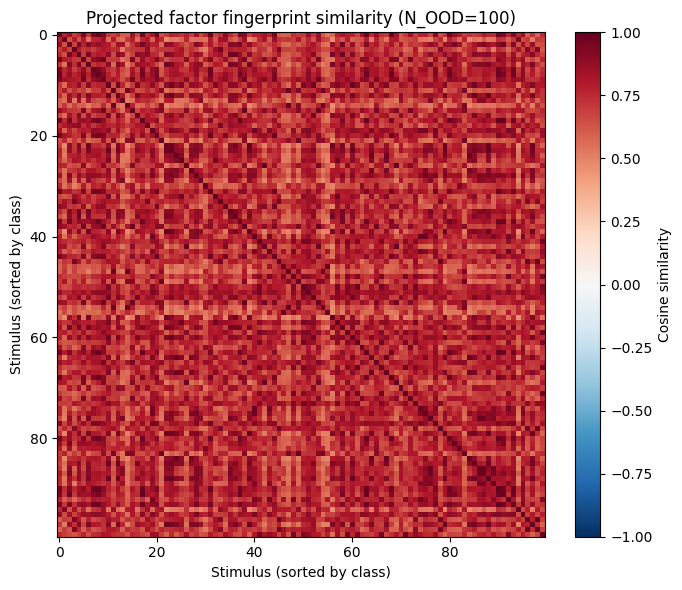

Fingerprint dim (projected): 22


In [15]:
# ── Fingerprint similarity for projected stimuli ──────────────────────────────
F_ood  = extract_fingerprint_matrix(projected_root, np.arange(N_OOD))
S_ood  = compute_stimulus_similarity(F_ood, metric='cosine')

sort_order = np.argsort(ood_targets)
S_ood_sorted = S_ood[np.ix_(sort_order, sort_order)]
targets_sorted = ood_targets[sort_order]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(S_ood_sorted, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1, interpolation='nearest')
fig.colorbar(im, ax=ax, label='Cosine similarity')

for cl in np.unique(targets_sorted):
    boundary = np.where(np.diff((targets_sorted == cl).astype(int)))[0]
    for b in boundary:
        ax.axhline(b + 0.5, color='k', lw=0.8)
        ax.axvline(b + 0.5, color='k', lw=0.8)

ax.set(title=f'Projected factor fingerprint similarity (N_OOD={N_OOD})',
       xlabel='Stimulus (sorted by class)', ylabel='Stimulus (sorted by class)')
plt.tight_layout()
plt.show()

print('Fingerprint dim (projected):', F_ood.shape[1])

## Notes

### To analyse truly out-of-distribution stimuli:

1. Collect activations for your new stimuli:
```python
from src import collect_layer_inputs
ood_data = collect_layer_inputs(model, ood_dataset, label_transform=None)
layer_inputs_ood = ood_data['layer_inputs']  # list[(N_ood, n_in)]
```

2. Project onto the fixed BFT factors:
```python
projected_root = project_stimuli_onto_tree(tree_root, layer_inputs_ood)
```

3. Run tree visualisation and fingerprint analyses using `projected_root` exactly as above.

### For adversarial stimuli:
Generate adversarial examples with your preferred attack, collect their activations via hooks or `collect_layer_inputs`, then proceed as above.

### Key functions:
| Function | Purpose |
|---|---|
| `extract_tree_nodes(root)` | Flat BFS list of tree node metadata |
| `compute_node_activations(nodes, indices, mode)` | Scalar per-node activation for a stimulus set |
| `plot_factor_tree(nodes, activations)` | Tree diagram coloured by activation |
| `extract_factor_fingerprint(root, s)` | Factor fingerprint vector for stimulus s |
| `extract_fingerprint_matrix(root, indices)` | (n_stimuli, dim) fingerprint matrix |
| `compute_stimulus_similarity(F, metric)` | Pairwise cosine/correlation similarity |
| `project_stimuli_onto_tree(root, new_inputs)` | NNLS projection of new stimuli onto fixed factors |